In [1]:
using LinearAlgebra
using Plots
using Plots.Measures

default(leftmargin = 5mm, bottommargin = 5mm)


# Questão 1



## Letra a )

A questão já nos define que $Q_v = I - \beta vv^*$ e $Q_vx = \| x \| e_1$. Vamos analisar, agora, o que é pedido. Primeiramente, vamos verificar que $v = x - \|x \| e_1$,

$$ Q_vx = \| x \| e_1 $$
$$ (I - \beta vv^*) x = \| x \| e_1 $$
$$ \beta v(v^* x) = x - \| x \| e_1 $$
$$  v =  \frac{x -\| x \| e_1}{\beta (v^* x)} $$

Como $\beta$ é uma constante qualquer, podemos definir nesse caso, sem perda de generalidade, $\beta = \frac{1}{(v^* x)}$, e portanto

$$ v = x - \| x \| e_1$$

$$ v = \begin{bmatrix} x_1 - \| x \| \\ x_2 \\ \vdots \\ x_n\end{bmatrix}$$

Agora, vamos verificar quem é $\beta$,  primeiramente, vamos dar uma olhada em $v^*x$. Podemos perceber que todas as entradas de $v$ são idênticas a de $x$, a menos da primeira, que é $x_1 - \| x \|$. Logo o produto interno $v^*x$ pode ser definido como 

$$ (x_1 - \| x \|)x_1 + \sum_{i = 2}^{n}x_i^2$$
$$ = \sum_{i = 1}^{n}x_i^2 - \|x\|x_1$$
$$=  \| x \|^2 - \|x\|x_1 $$
$$= \|x\|(\|x\| - x_1)$$
$$ \Longrightarrow \beta = \frac{1}{\|x\|(\|x\| - x_1)}$$

Portanto, a primeira igualdade de $\beta$ pedida pela questão foi provada, verifiquemos as outras

$$ \beta =  \frac{(\|x\| + x_1)}{\|x\|(\|x\| - x_1)(\|x\| + x_1)} = \frac{(\|x\| + x_1)}{\|x\|(\|x\|^2 - x_1^2)}$$

Sabemos que $\|x\|^2 = \sum_{i = 1}^{n}x_i^2 \Longrightarrow \|x\|^2  - x_1^2= \sum_{i = 2}^{n}x_i^2 = \|y\|^2$, como $y$ é definido pela questão, assim

$$\beta = \frac{(\|x\| + x_1)}{\|x\|\|y\|^2} $$

## Letra b )

Vamos verificar que alterações o sinal de $x_1$ pode provocar nas fórmulas para $\beta$, ou seja, segundo o informado pela questão, em qual das fórmulas estamos sujeitos a cancelamento numérico a depender do sinal de $x_1$, acredito que seja um pouco mais fácil de compreender através de como o $\textit{Trefethen}$ explica isso

Pelo que entendemos, o que queremos evitar aqui é o problema evitado por $\textit{Trefethen}$ ao selecionar $v$ como 

$$ v = sign(x_1)\|x\|e_1 + x$$

Ele faz isso para que $\|v\|$ seja a maior possível. Vamos identificar isso na prática, o que a formulação dele mudaria para nós é que

$$ v = \begin{bmatrix} x_1 + sign(x_1) \| x \| \\ x_2 \\ \vdots \\ x_n\end{bmatrix}$$

Ou seja, o que queremos evitar é a subtração entre $x_1$ e $\|x\|$.

1) Na primeira fórmula $$\beta = \frac{1}{\|x\|(\|x\| - x_1)}$$ temos a subtração $(\|x\| - x_1)$ que nos é favorável quando o sinal de $x_1$ é negativo, resultando na soma entre os dois termos.

2) Podemos identificar que na segunda fórmula, $$\frac{(\|x\| + x_1)}{\|x\|(\|x\|^2 - x_1^2)}$$ encontramos esse problema bem presente, já que independentemente do sinal de $x_1$ estamos sujeitos a esse erro por conta de $(\|x\|^2 - x_1^2)$.

3) Na terceira fórmula, $$\beta = \frac{(\|x\| + x_1)}{\|x\|\|y\|^2} $$ podemos perceber que $(\|x\| + x_1)$ nos é favorável quando o sinal de $x_1$ é positivo.

## Letra c )

In [53]:
struct Reflector{T}
    v::Vector{T}
    beta::T
end

function reflector(x; verbose= false)
    sign_x1 = x[1] >= 0 #True se positivo, False, se não
    type = eltype(x)
    norm_x = norm(x)

    v = copy(x)
    v[1] -= norm_x

    if sign_x1
        beta = (norm_x + x[1])/(norm_x * sum(abs2, @view x[2:end])) 
    else
        beta = 1/(norm_x*(norm_x - x[1]))
    end

    if type != eltype(v)
        println("O vetor mudou seu tipo de dado: $(eltype(v))")
    end

    if verbose
        println("Beta calculado: $beta")
        return Reflector(v, beta)
    else
        return Reflector(v, beta)
    end
end

reflector (generic function with 2 methods)

A função criada implementa a lógica formalizada pelas questões acima para calcular os parâmetros e $v$ e $\beta$ dos refletores. Sabemos a estrutura que $v$ deve ter e nos beneficiamos disso na função. Sabemos que $v$ é igual a $x$ com a primeira entrada modificada para $v_1 = x_1 - \|x\|$. Temos uma variável Booleana que indica o sinal da entrada $x_1$ e a partir dessa informação calculamos o $\beta$ de forma a não sofrer com cancelamento numérico.

## Letra d )

Consideremos $v$ como foi definido pela questão como uma função vetorial $v(x) = x - \|x\|e_1$, dessa forma, vamos calcular sua derivada em relação a $x$. Com $x$ tendo cada uma de suas entradas independentes, o que queremos calcular aqui é então a matriz Jacobiana

$$ J(v) = \begin{bmatrix} 
        \frac{\partial v_1}{\partial x_1} & \dots & \frac{\partial v_1}{\partial x_n} \\ 
        \vdots                            & \ddots&         \vdots                     \\ 
        \frac{\partial v_n}{\partial x_1} & \dots & \frac{\partial v_n}{\partial x_n}
        \end{bmatrix} $$

Para calcularmos, sabemos que 

$$ v = \begin{bmatrix} x_1 - \| x \| \\ x_2 \\ \vdots \\ x_n\end{bmatrix}$$

E portanto, vamos analisar cada entrada:

$$ \frac{\partial v_i}{\partial x_j} = 
\left\{
\begin{aligned}
1, \quad \text{se } i = j \\
0, \quad \text{se } i \neq j
\end{aligned}

\quad

\right. 

\text{para } i, j= 2, \dots,n$$

Vamos, agora, analisar as derivadas parciais de $v_1$ com relação as entradas de $x$, que sabemos que será da forma 

$$ \frac{\partial v_1}{\partial x_i} = \frac{x_1 - \| x \|}{\partial x_i} = \frac{x_1}{\partial x_i} - \frac{\| x \|}{\partial x_i} \quad \text{para } i = 1,\dots,n$$

Sabemos que 
$$ \frac{x_1}{\partial x_i} = 
\left\{
\begin{aligned}
1, \quad \text{se } i = j \\
0, \quad \text{se } i \neq j
\end{aligned}

\right.
\quad
\text{para } i= 1, \dots,n$$

$$\|x\| = \sqrt{\sum_{i=1}^{n}x_1^2}, \quad y = \sum_{i=1}^{n}x_1^2  \Longrightarrow   \frac{\|x\|}{\partial x_i} = \frac{\partial \|x\|}{\partial y} \frac{\partial y}{\partial x_i} = \frac{1}{ 2\sqrt{y}} 2 x_i = \frac{\partial x_1}{\|x\|}$$

Portanto, nossa matriz se torna 

$$ J(v) = \begin{bmatrix} 
        1 -  \frac{\partial x_1}{\|x\|}& - \frac{\partial x_2}{\|x\|} & \dots & - \frac{\partial x_n}{\|x\|}\\ 
                                  & 1 &                      &        \\ 
          &  & \ddots &  \\
          &  & & 1
        \end{bmatrix}_{n \times n}
        
= I_{n \times n} + \begin{bmatrix} 
        -\frac{\partial x_1}{\|x\|} & \dots & -\frac{\partial x_n}{\|x\|}\\ 
           \\
          & 0_{(n -1) \times n} \\
           \\
        \end{bmatrix}_{n \times n}
        
= I + e_1 \frac{x^*}{\|x\|}$$

Sabemos que o condicionamento absoluto de uma função $f$ é dado em termos de sua matriz Jacobiana, assim

$$ k =  \|J\| = \| I + e_1 \frac{x^*}{\|x\|}\| \leq  \| I \| +  \| e_1 \frac{x^*}{\|x\|}\| = 1 + \frac{1}{\|x\|}\|e_1x^*\| = 1 +  \frac{1}{\|x\|}\|e_1\|\|x\|$$
Como $\|e_1\| = 1$, então

$$ k \leq 1+ \frac{\|x\|}{\|x\|} = 2$$

## Letra e )

Como requisitado pela questão faremos testes com vetores $x$ com entradas aleatórias nos tipos $\textit{Float32}$ e $\textit{Float64}$

In [49]:
# O objetivo da nossa função é testar se nossa matriz Q é ou está próxima de ser ortogonal
# e se ao aplicarmos nosso refletor ao vetor as entradas são realmente canceladas

function test_reflector(n, type= Float64)
    x = rand(type, n)
    ref = reflector(x)
    
    v = ref.v
    Q = I - ref.beta * (v * v')
    
    Qx = Q * x
    res1 = norm(Qx[2:end]) 
    
    res2 = norm(Q' * Q - I)
    
    println("$type (n=$n):")
    println(" - Testes das entradas zeradas: ", res1)
    println(" - Teste de Ortogonalidade: ", res2)
end

test_reflector (generic function with 2 methods)

In [15]:
test_reflector(10, Float64)
test_reflector(10, Float32)

Float64 (n=10):
 - Testes das entradas zeradas: 4.987969362527024e-16
 - Teste de Ortogonalidade: 9.012424781263402e-16
Float32 (n=10):
 - Testes das entradas zeradas: 8.11331e-8
 - Teste de Ortogonalidade: 2.0376272e-7


In [20]:
test_reflector(50, Float64)
test_reflector(50, Float32)

Float64 (n=50):
 - Testes das entradas zeradas: 9.708833326590948e-16
 - Teste de Ortogonalidade: 1.6452813328305082e-15
Float32 (n=50):
 - Testes das entradas zeradas: 8.0432653e-7
 - Teste de Ortogonalidade: 9.917972e-7


In [19]:
test_reflector(100, Float64)
test_reflector(100, Float32)

Float64 (n=100):
 - Testes das entradas zeradas: 9.262579859324414e-16
 - Teste de Ortogonalidade: 2.286313416053465e-15
Float32 (n=100):
 - Testes das entradas zeradas: 2.767628e-7
 - Teste de Ortogonalidade: 1.3725326e-6


## Letra f ) 

Sabemos que a matriz $Q_v$ não está definida como normalmente. $\textit{Trefthen}$ define $Q_v = I - 2\frac{vv^*}{v^*v}$, portanto, $\beta$ em função apenas de $v$ é

In [54]:
function calc_beta(v; verbose = false)   
    v_dot = sum(abs2, v)
    beta = 2/v_dot
    
    if verbose
        println("Beta calculado por v: ", beta)
    else
        return beta
    end
end

calc_beta (generic function with 2 methods)

In [72]:
function compare_beta(n, type= Float64; align_e1= true)
    if align_e1
        x = rand(type, n) * 1e-10
        x[1] += 1
    else
        x = rand(type, n)
    end
    
    println("$type (n=$n):")
    ref = reflector(x, verbose= true)
    beta = calc_beta(ref.v, verbose= true)
end

compare_beta (generic function with 2 methods)

In [66]:
compare_beta(10, Float64)
compare_beta(10, Float32)

Float64 (n=10):
Beta calculado: 0.2446867022708727
Beta calculado por v: 0.2446867022708727
Float32 (n=10):
Beta calculado: 0.31846192
Beta calculado por v: 0.31846195


In [67]:
compare_beta(50, Float64)
compare_beta(50, Float32)

Float64 (n=50):
Beta calculado: 0.05870023469855948
Beta calculado por v: 0.05870023469855946
Float32 (n=50):
Beta calculado: 0.09218042
Beta calculado por v: 0.09218044


In [71]:
compare_beta(100, Float64)
compare_beta(100, Float32)

Float64 (n=100):
Beta calculado: 0.035126146485261765
Beta calculado por v: 0.03512614648526176
Float32 (n=100):
Beta calculado: 0.032780707
Beta calculado por v: 0.032780707


Vamos verificar agora o caso pedido pela questão em que $x$ está quase alinhado com $e_1$


In [74]:
compare_beta(10, Float64, align_e1= true)
compare_beta(10, Float32, align_e1= true)

Float64 (n=10):
Beta calculado: 4.344081743724723e19
Beta calculado por v: 4.344081743724723e19
Float32 (n=10):
Beta calculado: 9.010048439422244e19
Beta calculado por v: 9.010048439422244e19


In [83]:
compare_beta(50, Float64, align_e1= true)
compare_beta(50, Float32, align_e1= true)

Float64 (n=50):
Beta calculado: 1.3515475283231726e19
Beta calculado por v: 1.3515475283231726e19
Float32 (n=50):
Beta calculado: 1.2748708969337694e19
Beta calculado por v: 1.2748708969337694e19


In [73]:
compare_beta(100, Float64, align_e1= true)
compare_beta(100, Float32, align_e1= true)

Float64 (n=100):
Beta calculado: 7.12718487353145e18
Beta calculado por v: 7.127184873531451e18
Float32 (n=100):
Beta calculado: 6.407227704037836e18
Beta calculado por v: 6.407227704037836e18


Podemos verificar então que realmente não há muita diferença ao calcular $\beta$ a partir de $v$ ou de $x$.

# Questão 2 



## Letra a )

Nesse caso, nós já conhecemos os parâmetros $v$ e $\beta$ dos refletores, assim, vamos verificar o que nós precisamos computar. Queremos calcular $$Q_vb = (I - \beta vv^*) b = b - \beta(v^*b) v = b - \alpha v$$

Para conseguirmos fazer o calculo com $v$ e $b$ de tamanhos diferentes vamos aplicar $v$ apenas na parte inferior correspondente de $b$ através da indexação

In [109]:
function apply_reflector(v, beta, b)
    n_v = length(v)
    n_b = length(b)

    k = n_b - n_v + 1
    b_view = @view b[k:end]

    alpha = beta * dot(v, b_view)
    b_view .-= alpha .* v
    
    return b
end

apply_reflector (generic function with 1 method)

## Letra b )

Vamos realizar os testes pedidos iniciando com vetores de mesma dimensão que $v$. Sabemos que a aplicação da nossa matriz $Q_v$ não deve alterar a norma do nosso vetor, portanto, vamos verififcar se isso realmente acontece.

In [144]:
function test_reflector(n_v, n_b)
    b = rand(n_b)
    norm_b = norm(b)
    
    x = rand(n_v)
    ref = reflector(x)

    b_mod = apply_reflector(ref.v, ref.beta, b)
    norm_b_mod = norm(b_mod)
    
    println("Norma do vetor original: ", norm_b)
    println("Norma do vetor modificado: ", norm_b_mod)
end

test_reflector (generic function with 2 methods)

- Testes com vetores de mesma dimensão

In [146]:
test_reflector(15,15)

Norma do vetor original: 2.2491212450595066
Norma do vetor modificado: 2.249121245059506


In [150]:
test_reflector(40,40)

Norma do vetor original: 3.6872790234188693
Norma do vetor modificado: 3.6872790234188693


In [151]:
test_reflector(150,150)

Norma do vetor original: 7.406344859801322
Norma do vetor modificado: 7.406344859801322


- Testes com vetores de dimensão diferente

In [147]:
test_reflector(5,50)

Norma do vetor original: 4.245919706324302
Norma do vetor modificado: 4.245919706324302


In [148]:
test_reflector(10,120)

Norma do vetor original: 6.566882668710179
Norma do vetor modificado: 6.5668826687101785


In [152]:
test_reflector(130,150)

Norma do vetor original: 7.311448164997424
Norma do vetor modificado: 7.311448164997427


Nossa função `apply_reflector` calcula o produto interno entre $v$ e as entradas correspondentes de $b$ e depois calcula o produto de um escalar por um vetor e uma subtração das entradas correspondentes em $b$ por outro vetor. Assim, concluímos que a complexidade final da nossa função é $O(n)$.

## Letra c )

O que nós queremos fazer agora é generalizar nossa função criada acima para calcular as reflexões em uma matriz, dessa forma a operação será $$Q_v A = (I - \beta v v^*)A = A - \beta v(v^*A)$$

In [92]:
function apply_reflector(v, beta, A)
    n_v = length(v)
    m, n = size(A)

    if m >= n_v
        k = m - n_v + 1

        A_view = @view A[k:end,:]
        vA = v'*A_view
        beta_v = beta .* v
        A_view .-= beta_v * vA
    
        return A
    end
end

apply_reflector (generic function with 1 method)

## Letra d )

A aplicação da da matriz $Q_v$ pela direita faz $$AQ_v = A(I - \beta vv^*) = A- \beta(Av)v^* $$

In [91]:
function rev_apply_reflector(v, beta, A)
    n_v = length(v)
    m, n = size(A)

    if n >= n_v
        k = n - n_v + 1

        A_view = @view A[:,k:end]
        Av = A_view*v
        beta_v = beta .* v'
        A_view .-=  Av * beta_v
    
        return A
    end
end



rev_apply_reflector (generic function with 1 method)


## Letra e )

In [ ]:
function to_hessemberg(A; return_Q = false)
    H = copy(A)
    m, n = size(H)
    reflectors = []

    if return_Q
        Q = Matrix{eltype(H)}(I, n, n)
    end

    for j in 1:(n-2)
        x = @view H[(j+1):end,j]

        r = reflector(x)
        push!(reflectors, r)

        apply_reflector(r.v, r.beta, @view H[(j+1):end, j:end])
        rev_apply_reflector(r.v, r.beta, @view H[:, (j+1):end])

        if return_Q
            rev_apply_reflector(r.v, r.beta, @view Q[:, (j+1):end])
        end
    end

    if return_Q
        return reflectors, H, Q
    else
        return reflectors, H
    end
end

to_hessemberg (generic function with 1 method)

## Letra f )

# Questão 3

 

## Letra a)

Vamos analisar melhor o que é esse tipo de matriz que nos foi dada:

$$ A(w) = \begin{bmatrix} 0 & 1 \\ -w^2 & 0\end{bmatrix}$$

Primeiramente, dado que a letra c) pede para fazermos, vamos verificar o que acontece quando fazemos $A(w)^2$

$$ A(w)^2 = \begin{bmatrix} 0 & 1 \\ -w^2 & 0\end{bmatrix}\begin{bmatrix} 0 & 1 \\ -w^2 & 0\end{bmatrix} = \begin{bmatrix}  -w^2 & 0 \\ 0 &  -w^2\end{bmatrix} = -w^2I$$

O que conseguimos deduzir disso, à princípio é que seja $\lambda$ um autovalor de $A(w)$ e $v$ seu autovetor associado, então $$A(w)^2 v = \lambda^2v \Longrightarrow \lambda^2 = -w^2 \Longrightarrow \lambda_1 = \sqrt{-w^2} = iw \quad \text{e} \quad \lambda_2 = - \sqrt{-w^2} = -iw $$

Ou seja, nossos autovalores só possuem a parte complexa.

Vamos encontrar nossos autovetores, sabemos que $(A - \lambda I)v = 0$, assim

$$ \begin{bmatrix} -\lambda & 1 \\ -w^2 & -\lambda\end{bmatrix} \begin{bmatrix} v_1 \\ v_2\end{bmatrix} = \begin{bmatrix} 0 \\ 0\end{bmatrix} \Longrightarrow v_2 = iwv_1 \quad \text{ou} \quad v_2 = -iwv_1$$

Dessa forma, $$ v_1 = \begin{bmatrix} 1 \\ iw\end{bmatrix} \quad v_2 = \begin{bmatrix} 1 \\ -iw\end{bmatrix}  $$

A partir dessas conclusões, podemos esperar que com $ w \rightarrow 0^+ $ nossos autovalores $|\lambda_1| , |\lambda_2| \rightarrow 0$ e nossos autovetores $v_1, v_2 \rightarrow \begin{bmatrix} 1 \\ 0\end{bmatrix}$. Vamos verificar em código,

In [155]:
function plot_eigen_values(w_max; ascending= true, imag_only= false)

    if ascending
        range = 0.0:0.03:w_max
    else
        range = w_max:-0.03:0.0
    end

    if imag_only
        im_lambda1 = Float64[]
        im_lambda2 = Float64[]
        
        for w in range
            A = [0.0 1.0; -w^2 0.0]
            
            eigen_A = eigen(A)

            push!(im_lambda1, imag(eigen_A.values[1]))
            push!(im_lambda2, imag(eigen_A.values[2]))
        end
        
        p1 = scatter(range, im_lambda1, label="Imag(λ₁)", linewidth=2, color=:red, title="Autovalores", xlabel="w", ylabel="Parte Imaginária")
        scatter!(p1, range, im_lambda2, label="Imag(λ₂)", linewidth=2, color=:blue)
    
        if ascending
            display(scatter(p1, size=(600, 400)))
        else
            display(scatter(p1, size=(600, 400), x_flip= true))
        end

    else
        real_lambda1 = Float64[]
        real_lambda2 = Float64[]
        im_lambda1 = Float64[]
        im_lambda2 = Float64[]
        
        for w in range
            A = [0.0 1.0; -w^2 0.0]
            
            eigen_A = eigen(A)

            push!(real_lambda1, real(eigen_A.values[1]))
            push!(real_lambda2, real(eigen_A.values[2]))
            push!(im_lambda1, imag(eigen_A.values[1]))
            push!(im_lambda2, imag(eigen_A.values[2]))
        end
        
        p1 = scatter(real_lambda1, im_lambda1, label="(λ₁)", linewidth=2, color=:red, title="Autovalores", xlabel="w", ylabel="Parte Imaginária")
        scatter!(p1, real_lambda2, im_lambda2, label="(λ₂)", linewidth=2, color=:blue)
    
        if ascending
            display(scatter(p1, size=(600, 400)))
        else
            display(scatter(p1, size=(600, 400), x_flip= true))
        end
    end
    

end

plot_eigen_values (generic function with 1 method)

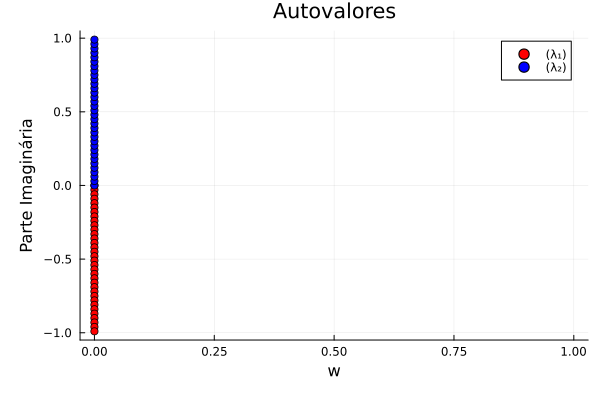

In [160]:
plot_eigen_values(1; ascending= true, imag_only= false)

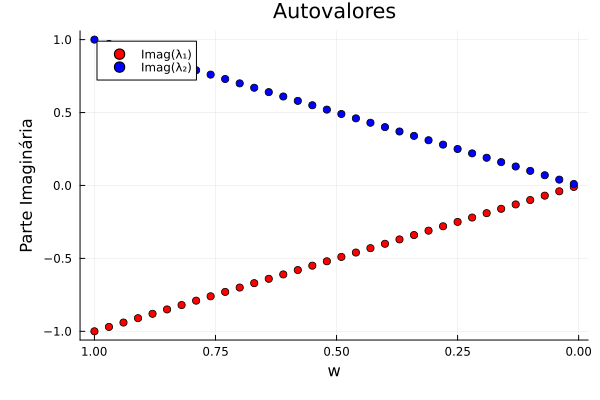

In [159]:
plot_eigen_values(1; ascending= false, imag_only= true)

In [153]:
function plot_eigen_vectors(w_max; ascending= true)

    if ascending
        range = 0.0:0.05:w_max
    else
        range = w_max:-0.03:0.0
    end

    real_v1 = Float64[]
    real_v2 = Float64[]
    imag_v1 = Float64[]
    imag_v2 = Float64[]
    

    for w in range
        A = [0.0 1.0; -w^2 0.0]
        eigen_A = eigen(A)

        v1 = eigen_A.vectors[:,1]
        v2 = eigen_A.vectors[:,2]

        r_v1 = real(v1[1])
        r_v2 = real(v2[1])
        im_v1 = imag(v1[2])
        im_v2 = imag(v2[2])

        push!(real_v1, r_v1)
        push!(real_v2, r_v2)
        push!(imag_v1, im_v1)
        push!(imag_v2, im_v2)

    end

    # p1 = scatter(range, real_v1, title= "v1 real")
    # p2 = scatter(range, real_v2, title = "v2 real")
    # p3 = scatter(range, imag_v1)
    # p4 = scatter(range, imag_v2)

    p1 = scatter(real_v1, xlims = (0,1), ylims = (-1,1), imag_v1, title= "v1")
    p2 = scatter(real_v2, xlims = (0,1), ylims = (-1,1), imag_v2, title = "v2")

    # plot(p1, p3, p2, p4, layout= (1,2), size= (800,800), x_flip= true)
    plot(p1, p2, layout= (1,2), size= (800,400))

end

plot_eigen_vectors (generic function with 1 method)

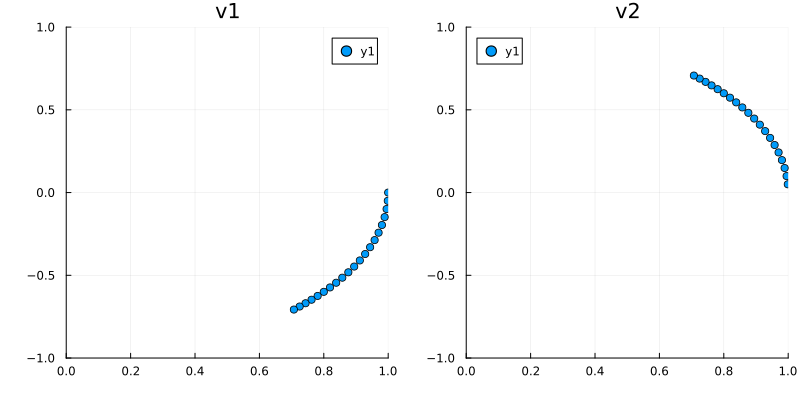

In [154]:
plot_eigen_vectors(1, ascending= true)

## Letra b )

Fazendo os cálculos, basicamente, verificando $A^*A$, encontrando os valores singulares, verificando que $V=I$, encontrando $U$, chegamos à conclusão de que a SVD de $A(w)$ é

$$ A(w) = \begin{bmatrix} 0 & 1 \\ -1 & 0\end{bmatrix} \begin{bmatrix} w^2 & 0 \\ 0 & 1\end{bmatrix} \begin{bmatrix} 1 & 0 \\ 0 & 1\end{bmatrix}$$

Sabemos que $$k(A) = \frac{\sigma_{max}}{\sigma_{min}}$$

Logo, como $w^2 \leq 1$ para $w \in [0,1]$, então temos que $$k(A) = \frac{1}{w^2}$$

## Letra c )

Primeiramente vamos demonstrar $A(\omega)^2 = - \omega I $:

$$
A(\omega)^2 = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}
\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}

= \begin{bmatrix} -\omega^2 & 0 \\ 0 & -\omega^2 \end{bmatrix}
= -\omega^2 \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
= -\omega^2 I
$$

E para a dedução, sabems que:
$$
e = \sum_{i=0}^{\infty} \frac{x^n}{n!}
$$
E portanto:
$$
e^{t A(\omega)} = \sum_{i=0}^{\infty} \frac{(t A(\omega))^n}{n!}
$$
Abrindo nós obtemos:
$$
e^{t A(\omega)} = \frac{(t A(\omega))^0}{0!} + \frac{(t A(\omega))^1}{1!} + \frac{(t A(\omega))^2}{2!} + \frac{(t A(\omega))^3}{3!} + ...
= I + t A(\omega) - \frac{t^2  \omega^2 I}{2!} - \frac{t^3  \omega^2 A(\omega)}{3!} + ...\\
$$
Dividindo os termos de expoente ímpar por $\omega$:
$$
e^{t A(\omega)} = I + \frac{t A(\omega)}{\omega} - \frac{t^2  \omega^2 I}{2!} - \frac{t^3  \omega^3 A(\omega)}{3! \omega} + ...\\
$$
Chegamos a dois somatórios um para os termos de grau ímpar e outro para termos de grau par:
$$
e^{t A(\omega)} = \sum_{i=0}^{\infty} \frac{(-1)^n}{(2n)!} (\omega t)^{2n} I + \sum_{j=0}^{\infty} \frac{(-1)^n}{(2n + 1)!} (\omega t)^{2n + 1} A(\omega)
$$
